# Option Analysis
This notebook analyzes the behavior of **put** options according to expiration time. Option price and the most common greeks are evaluated. Analysis is done for sets of distances of the strike price from the underlying, subdividing plots in three groups: OTM, ATM, ITM.

## Notation
- `S` is the **underlying price**
- `K` is the **strike price**
- `r` is the **risk-free** rate, can be set to `0`
- `T` is the **time** in years
- `sigma` is the **volatility**

## Imports and Variables

In [32]:
import numpy as np
import os
from matplotlib import pyplot as plt
from math import log, sqrt, exp, erf, pi


r = 0.00
S = 5000
K = 4600
T = 30/365
sigma = 0.15
option_type="p"

figure_folder = "figures"

## Set strike prices

In [ ]:
def compute_strike_from_distance(S, d):
    return S*(1+d/100)

np.set_printoptions(suppress=True) # avoid printing numbers in scientific notation

otm_distances = np.arange(-3, -11, -1) # in percentage
otm_strike_array = [compute_strike_from_distance(S, d) for d in otm_distances]

otm_strike_distances = np.empty([len(otm_distances), 2], dtype=np.int16)
otm_strike_distances[:, 0] = otm_distances
otm_strike_distances[:, 1] = otm_strike_array

print(f"Format: distance (%) | strike value. Spot price: {S}\n")
print("Underlying OTM values:")
print(otm_strike_distances)

atm_distances = [-0.5, -0.25, 0.25, 0.5] # in percentage
atm_strike_array = [compute_strike_from_distance(S, d) for d in atm_distances]

atm_strike_distances = np.empty([len(atm_distances), 2])
atm_strike_distances[:, 0] = atm_distances
atm_strike_distances[:, 1] = atm_strike_array

print("\n\nUnderlying ATM values:")
print(atm_strike_distances)

itm_distances = np.arange(1, 4) # in percentage
itm_strike_array = [compute_strike_from_distance(S, d) for d in itm_distances]

itm_strike_distances = np.empty([len(itm_distances), 2], dtype=np.int16)
itm_strike_distances[:, 0] = itm_distances
itm_strike_distances[:, 1] = itm_strike_array

print("\n\nUnderlying ITM values:")
print(itm_strike_distances)

Format: distance (%) | strike value. Spot price: 5000

Underlying OTM values:
[[  -3 4850]
 [  -4 4800]
 [  -5 4750]
 [  -6 4700]
 [  -7 4650]
 [  -8 4600]
 [  -9 4550]
 [ -10 4500]]


Underlying ATM values:
[[  -0.5  4975.  ]
 [  -0.25 4987.5 ]
 [   0.25 5012.5 ]
 [   0.5  5025.  ]]


Underlying ITM values:
[[   1 5050]
 [   2 5100]
 [   3 5150]]


## Black&Sholes Functions

In [34]:
def norm_cdf(x):
    return 0.5*(1 + erf(x/sqrt(2)))

def norm_pdf(x):
    return (1/sqrt(2*pi))*exp(-0.5*x*x)

def compute_d1(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return np.nan
    return (log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*sqrt(T))

def compute_d2(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return np.nan
    return compute_d1(S, K, T, r, sigma) - sigma*sqrt(T)

def black_scholes_price(option_type, S, K, T, r, sigma):
    if T <= 0:
        if option_type.lower() == "c":
            return max(S - K, 0)
        elif option_type.lower() == "p":
            return max(K - S, 0)
        else:
            raise ValueError("option_type must be 'c' for call or 'p' for put")

    d1 = compute_d1(S, K, T, r, sigma)
    d2 = compute_d2(S, K, T, r, sigma)

    if option_type.lower() == "c":
        return S*norm_cdf(d1) - K*exp(-r*T)*norm_cdf(d2)
    elif option_type.lower() == "p":
        return K*exp(-r*T)*norm_cdf(-d2) - S*norm_cdf(-d1)
    else:
        raise ValueError("option_type must be 'c' for call or 'p' for put")

def black_scholes_delta(option_type, S, K, T, r, sigma):
    if T <= 0:
        if option_type.lower() == "c":
            return 1.0 if S > K else 0.0
        elif option_type.lower() == "p":
            return -1.0 if S < K else 0.0
        else:
            raise ValueError("option_type must be 'c' for call or 'p' for put")

    d1 = compute_d1(S, K, T, r, sigma)

    if option_type.lower() == "c":
        return norm_cdf(d1)
    elif option_type.lower() == "p":
        return norm_cdf(d1) - 1
    else:
        raise ValueError("option_type must be 'c' for call or 'p' for put")

def black_scholes_gamma(option_type, S, K, T, r, sigma):
    if T <= 0:
        return 0.0

    d1 = compute_d1(S, K, T, r, sigma)
    return norm_pdf(d1)/(S*sigma*sqrt(T))

def black_scholes_theta(option_type, S, K, T, r, sigma):
    if T <= 0:
        return 0.0

    d1 = compute_d1(S, K, T, r, sigma)
    d2 = compute_d2(S, K, T, r, sigma)
    first_term = -(S*norm_pdf(d1)*sigma)/(2*sqrt(T))

    if option_type.lower() == "c":
        return first_term - r*K*exp(-r*T)*norm_cdf(d2)
    elif option_type.lower() == "p":
        return first_term + r*K*exp(-r*T)*norm_cdf(-d2)
    else:
        raise ValueError("option_type must be 'c' for call or 'p' for put")

""" def black_scholes_theta_daily(option_type, S, K, T, r, sigma):
    return black_scholes_theta(option_type, S, K, T, r, sigma)/365 """

def black_scholes_vega(option_type, S, K, T, r, sigma):
    if T <= 0:
        return 0.0

    d1 = compute_d1(S, K, T, r, sigma)
    return S*norm_pdf(d1)*sqrt(T)/100

## Make Time Array for each day of the month
Time is computed on a yearly scale to satisfy balck&sholes formula requirements

In [35]:
days_to_expiration = np.arange(0, 31)
annualized_days_to_expiration = [t/365 for t in days_to_expiration]

## Computation and Plot Function


In [36]:
def compute_and_plot_data(f, distances, ax, title, y_label):

    for distance in distances:
        d = distance[0]
        K = distance[1]
        price = [f(option_type, S, K, T, r, sigma) for T in annualized_days_to_expiration]
        ax.plot(days_to_expiration, price, label=f'Distance {d}% ({K})')
        
    ax.set_title(title) 
        
    ax.invert_xaxis()
    lgd = ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    ax.grid(axis="y")
    ax.set(xlabel='Days To Expiration', ylabel=y_label)
    #ax.label_outer()

    return lgd

def makeChart(f, y_label, sup_title, filepath):
    fig, (axOTM,axATM, axITM) = plt.subplots(3, figsize=(10,15))

    fig.subplots_adjust(top=0.88, hspace=0.4)

    lgdOTM = compute_and_plot_data(f, otm_strike_distances, axOTM, "OTM", y_label)

    lgdATM = compute_and_plot_data(f, atm_strike_distances, axATM, "ATM", y_label)

    lgdITM = compute_and_plot_data(f, itm_strike_distances, axITM, "ITM", y_label)

    sup = fig.suptitle(sup_title, y=0.92)

    plt.savefig(os.path.join(figure_folder,filepath), bbox_extra_artists=(lgdOTM,lgdATM,lgdITM, sup), bbox_inches='tight')

## Option Price Analysis
This analysis highlights the behavior over time of the option price according to the distance from strike price.

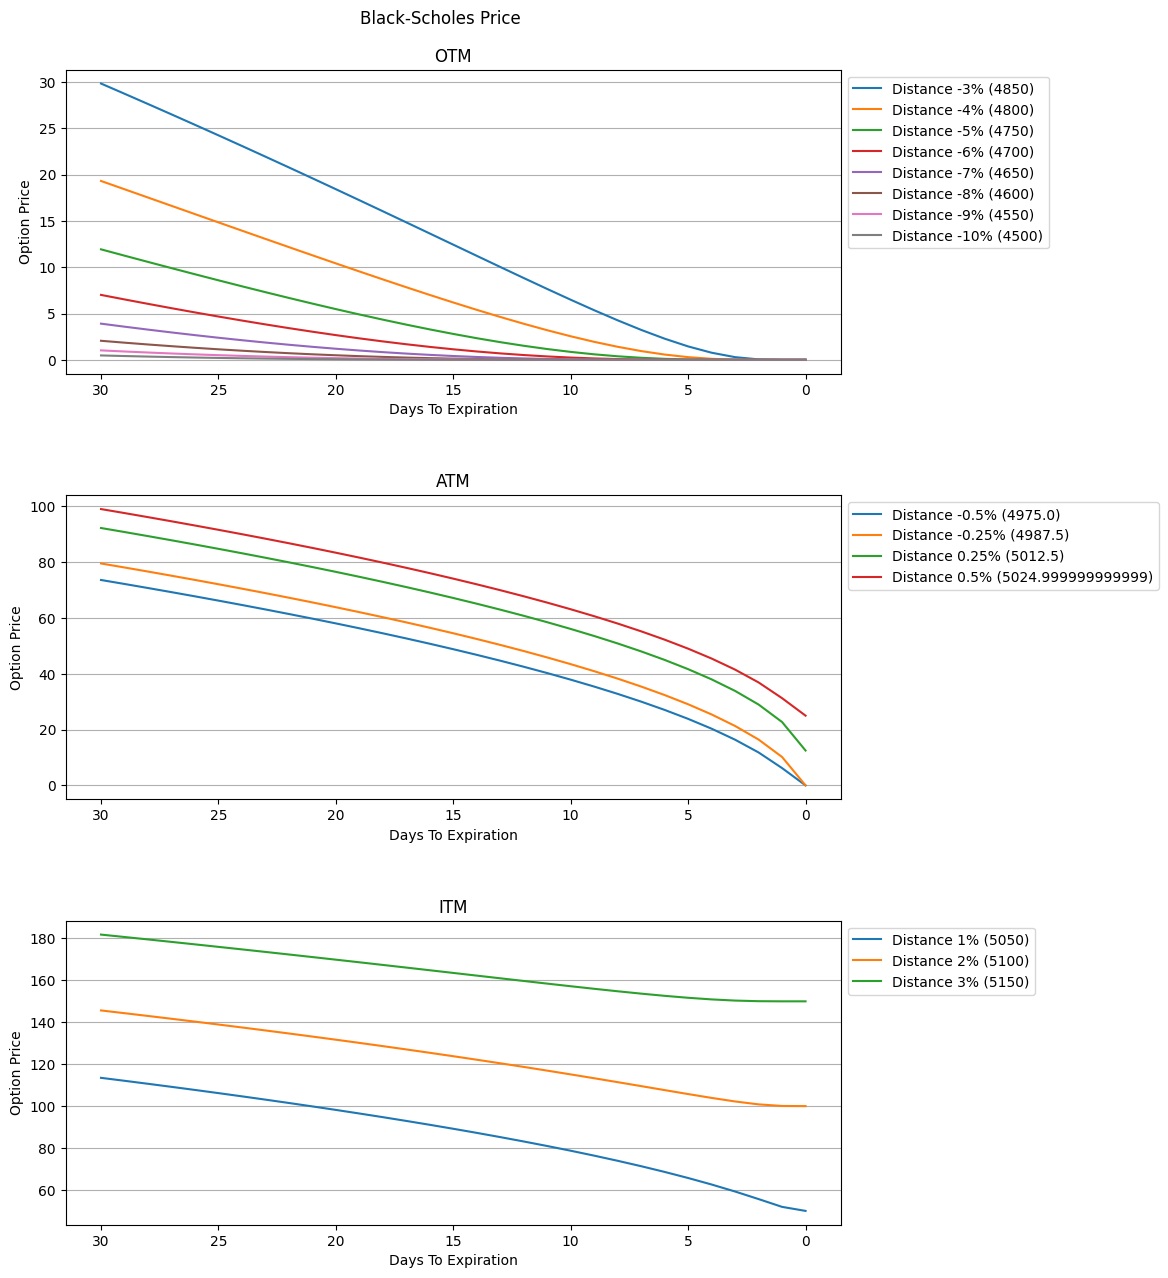

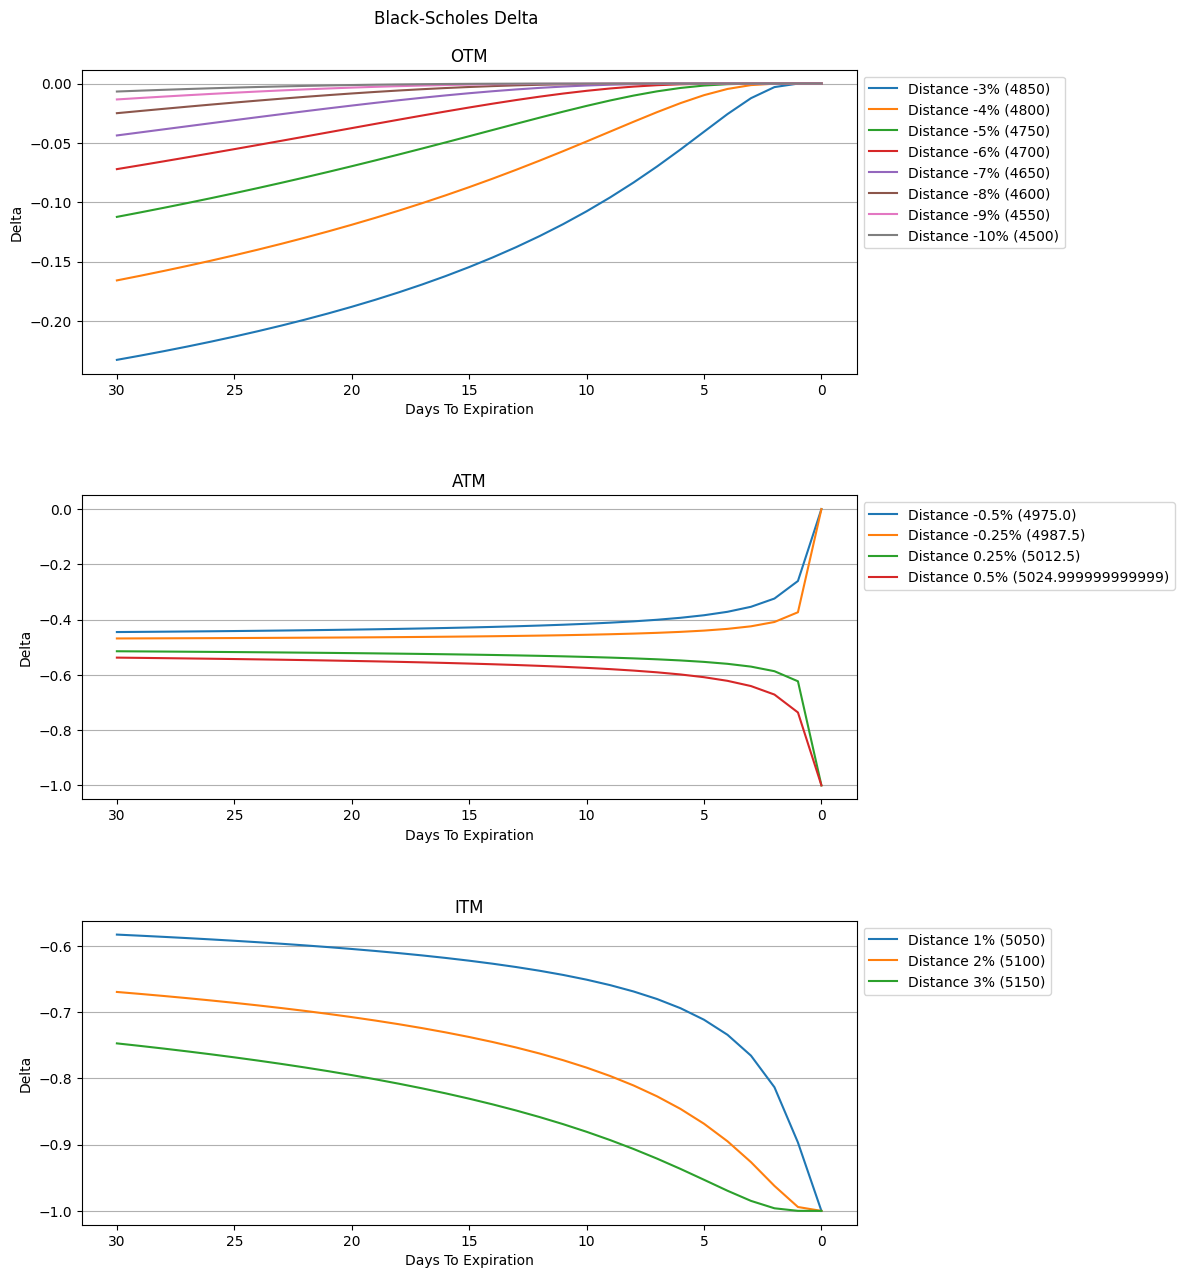

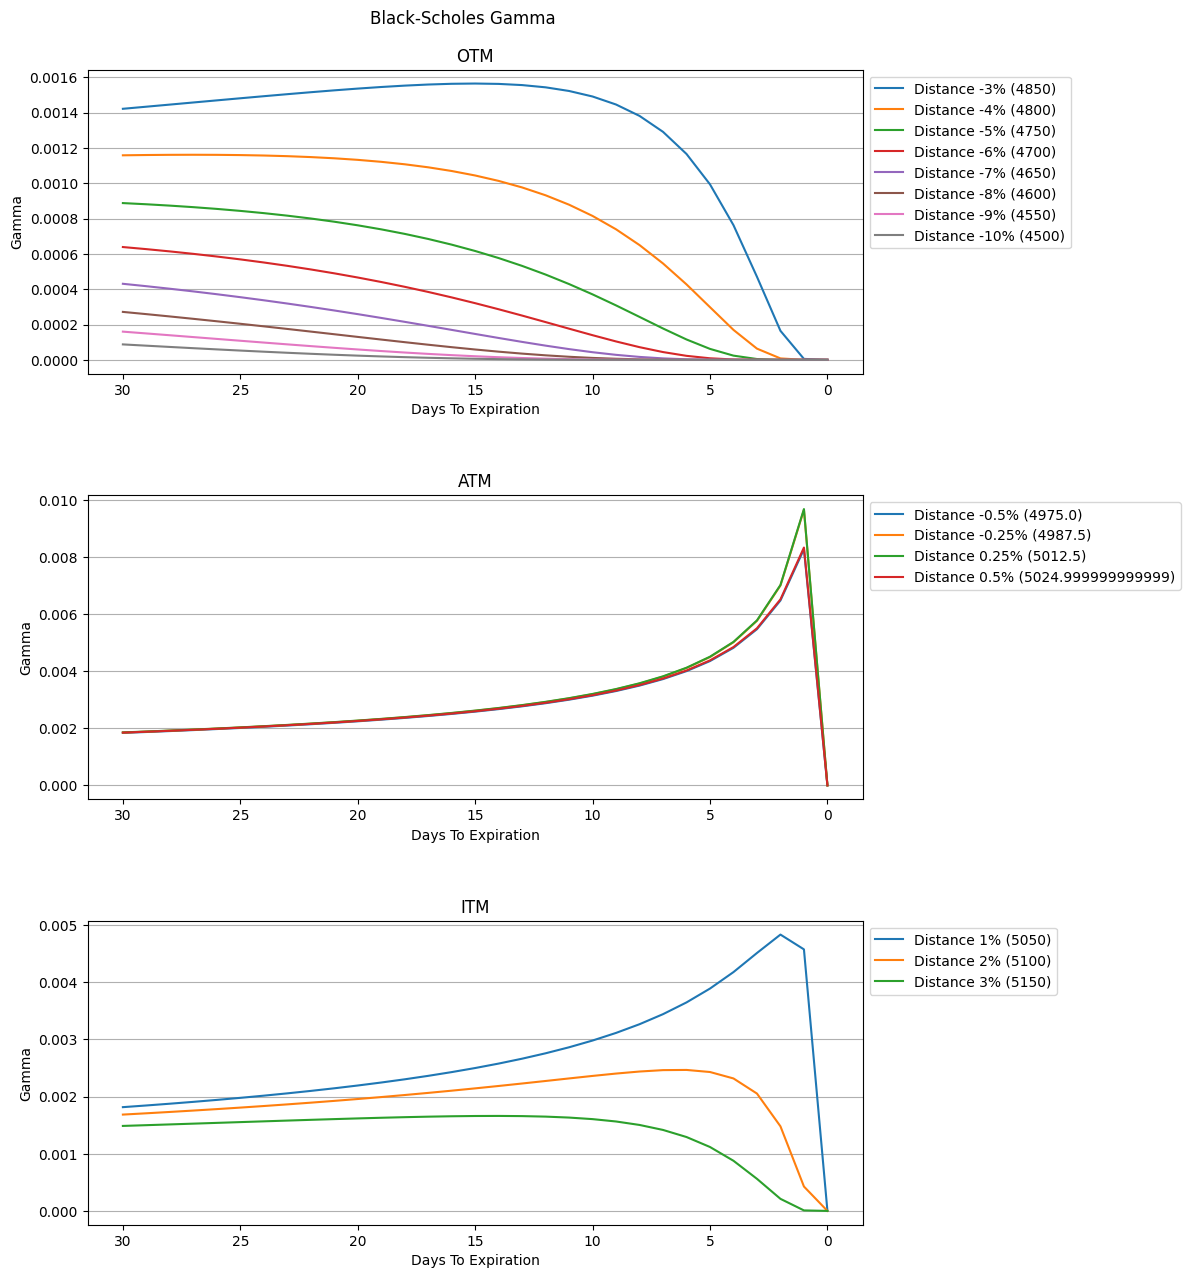

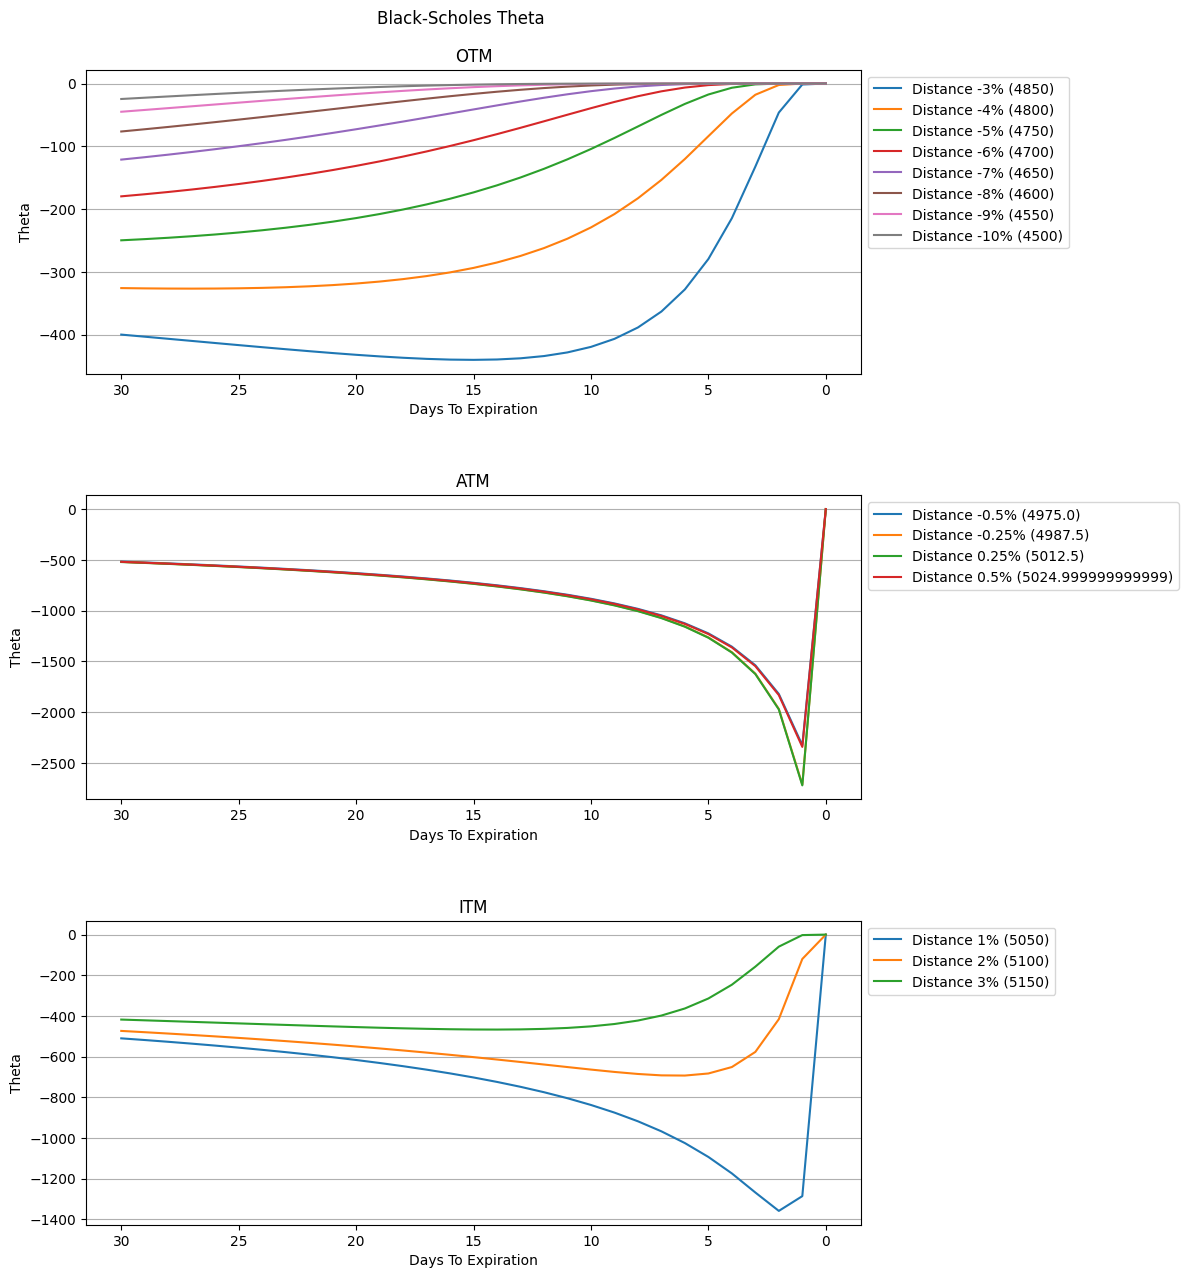

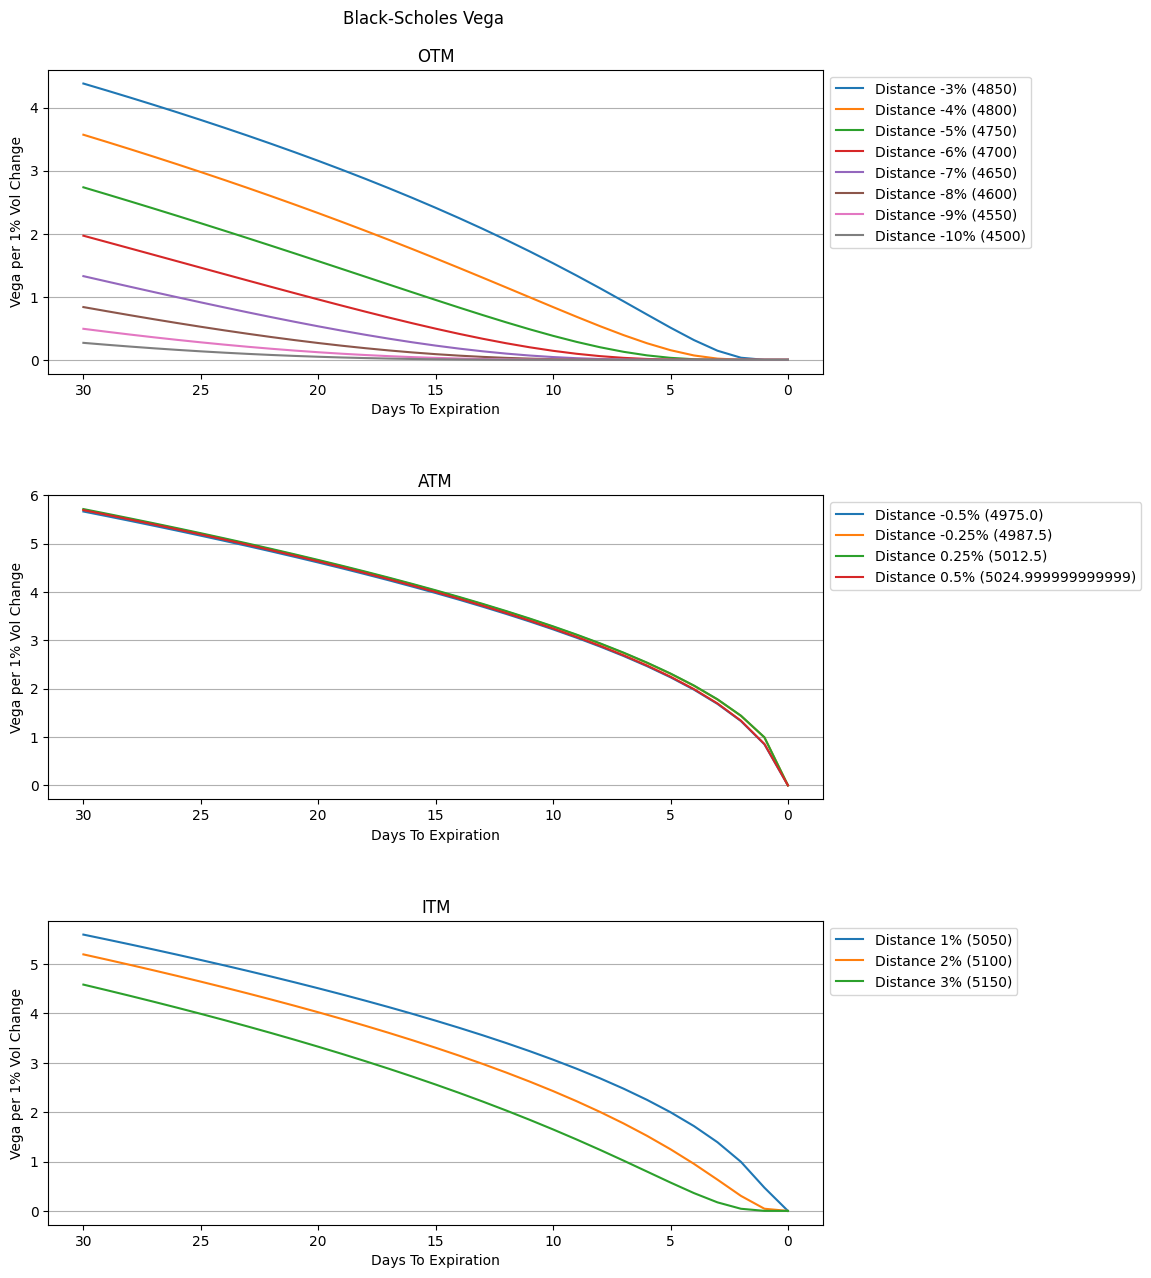

In [37]:
makeChart(black_scholes_price, "Option Price", "Black-Scholes Price", "black_scholes_price.png")
makeChart(black_scholes_delta, "Delta", "Black-Scholes Delta", "black_scholes_delta.png")
makeChart(black_scholes_gamma, "Gamma", "Black-Scholes Gamma", "black_scholes_gamma.png")
makeChart(black_scholes_theta, "Theta", "Black-Scholes Theta", "black_scholes_theta.png")
""" makeChart(black_scholes_theta_daily, "Theta Daily", "Black-Scholes Daily Theta", "black_scholes_theta_daily.png") """
makeChart(black_scholes_vega, "Vega per 1% Vol Change", "Black-Scholes Vega", "black_scholes_vega.png")